# AI-Generated Image Detection via VAE decoder (Final Component of VAE Generator)

Implementation of VAE decoder detector from **"Exploiting the Final Component of Generator Architectures for AI-Generated Image Detection"** (arXiv:2601.20461).

### Core idea
Every modern image generator ends with a *final component* — a VAE decoder for this notebook. They **contaminate** real images by passing them through that final component only, then train a binary classifier to tell real from contaminated. Because the same component is shared across generators, the detector generalises to unseen generators.

```
Real image  →  Encoder E*  →  z  →  Decoder φ*  →  Contaminated image
                                          ↓
               Detector θ  (DINOv2 backbone + FC layer)
               real = 1  |  AI-generated = 0
```

### Notebook structure
| # | Section |
|---|---|
| 0 | Imports & config & installations |
| 1 | Dataset — MS-COCO loader |
| 2 | Algorithm 1 — VAE contamination |
| 3 | Detector model — DINOv2 + FC head |
| 4 | Training loop (independent sampling) |
| 5 | Visualisation |

## 0 — Imports & config & Installations

In [ ]:
# ── standard library ─────────────────────────────────────────────────────────
import io, os, json, random, logging
from pathlib import Path

# ── numeric / vision ─────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from sklearn.metrics import accuracy_score, average_precision_score
from sklearn.metrics import pairwise_distances

# ── torch ecosystem ──────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.utils import make_grid

# ── generative model components ──────────────────────────────────────────────
from diffusers import AutoencoderKL
from transformers import AutoModelForCausalLM

logging.basicConfig(level=logging.INFO, format="%(asctime)s  %(message)s")
log = logging.getLogger()

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── global config  (edit these) ──────────────────────────────────────────────
CFG = dict(
    device         = "cuda" if torch.cuda.is_available() else "cpu",
    dtype          = torch.float16 if torch.cuda.is_available() else torch.float32,
    #device         = "cpu",

    # dataset
    coco_dir       = "PLEASE INPUT YOUR OWN PATH",   # path to MS-COCO images
    img_size       = 512,                      # resize target (VAE needs ≥64)
    n_real         = 1000,                     # real images to load for training

    # contamination
    vae_model_id   = "Manojb/stable-diffusion-2-1-base",
    vq_model_id    = "deepseek-ai/Janus-Pro-7B",
    vq_img_size    = 378,                      # Janus fixed input resolution
    sr_noise_t     = 500,                      # start timestep for SR noise
    sr_total_t     = 1000,
    sr_steps       = 50,

    # Algorithm 4
    k_medoids      = 100,                      # samples selected per component

    # detector
    backbone       = "dinov2_vitl14",          # or dinov2_vitb14 / vitg14
    lr             = 5e-7,
    batch_size     = 16,
    epochs         = 10,
    ckpt_path      = "/kaggle/working/detector.pth",

    # inference
    threshold      = 0.5,
)

Path(CFG["ckpt_path"]).parent.mkdir(parents=True, exist_ok=True)
print(f"Device: {CFG['device']}  |  dtype: {CFG['dtype']}")

Device: cuda  |  dtype: torch.float16


## 1 — Dataset — MS-COCO loader

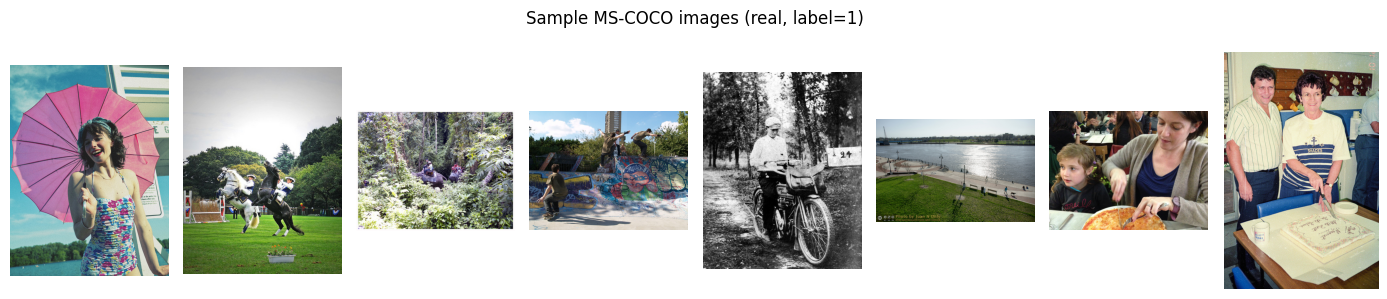

In [2]:
# ── transforms shared across all loaders ─────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_224 = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# VAE expects images in [-1, 1]
transform_vae = T.Compose([
    T.Resize(CFG["img_size"]),
    T.CenterCrop(CFG["img_size"]),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

# VQ / JanusPro expects ImageNet normalisation at its fixed resolution
transform_vq = T.Compose([
    T.Resize(CFG["vq_img_size"]),
    T.CenterCrop(CFG["vq_img_size"]),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# ── single unified Dataset ───────────────────────────────────────────────────
# A Dataset subclass is unavoidable: DataLoader requires __len__ and __getitem__.

class ImageFolderFlat(Dataset):
    """Load all JPG/PNG from a flat directory with a fixed label and transform."""
    def __init__(self, folder, transform, label, max_n=None):
        exts = {".jpg", ".jpeg", ".png"}
        self.paths = sorted(p for p in Path(folder).iterdir() if p.suffix.lower() in exts)
        if max_n:
            self.paths = self.paths[:max_n]
        self.transform = transform
        self.label = label

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), torch.tensor(self.label, dtype=torch.float32)


# ── helper: load a list of PIL images from a directory ───────────────────────
def load_pil_images(folder, max_n=None, size=None):
    """Return a list of PIL images. Optionally resize to (size, size)."""
    exts = {".jpg", ".jpeg", ".png"}
    paths = sorted(p for p in Path(folder).iterdir() if p.suffix.lower() in exts)
    if max_n:
        paths = paths[:max_n]
    images = []
    for p in paths:
        img = Image.open(p).convert("RGB")
        if size:
            img = img.resize((size, size))
        images.append(img)
    log.info(f"Loaded {len(images)} images from '{folder}'")
    return images, [str(p) for p in paths]


# ── quick sanity check ───────────────────────────────────────────────────────
if Path(CFG["coco_dir"]).exists():
    sample_pil, sample_paths = load_pil_images(CFG["coco_dir"], max_n=8)
    fig, axes = plt.subplots(1, 8, figsize=(14, 3))
    for ax, img in zip(axes, sample_pil):
        ax.imshow(img)
        ax.axis("off")
    plt.suptitle("Sample MS-COCO images (real, label=1)", fontsize=12)
    plt.tight_layout()
    plt.show()

## 2 — VAE contamination

Pass real images through the SD 2.1 **VAE encoder then decoder**. The round-trip introduces the decoder's characteristic imprint while preserving semantic content.

In [ ]:
hf_token = "PLEASE PUT YOUR OWN HUGGING FACE TOKEN"
from huggingface_hub import login
login(hf_token)

In [4]:
from diffusers import StableDiffusionPipeline, EulerDiscreteScheduler
import torch

model_id = "Manojb/stable-diffusion-2-1-base"

# Scheduler compatible SD 2.1
scheduler = EulerDiscreteScheduler.from_pretrained(model_id, subfolder="scheduler")

# Chargement du pipeline correct pour SD 2.1
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    scheduler=scheduler,
    torch_dtype=torch.float16
)


pipe.enable_model_cpu_offload()
#pipe.enable_vae_slicing()
#pipe = pipe.to("cuda")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


scheduler_config.json:   0%|          | 0.00/346 [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/543 [00:00<?, ?B/s]

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--Manojb--stable-diffusion-2-1-base/snapshots/0094d483a120f3f33dafbd187ea4aa60d10de75c/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
# ── load VAE ─────────────────────────────────────────────────────────────────
log.info(f"Loading VAE from '{CFG['vae_model_id']}'...")
vae = AutoencoderKL.from_pretrained(
    CFG["vae_model_id"], subfolder="vae"
).to(device=CFG["device"], dtype=CFG["dtype"])
vae.eval()

# Vérifie le type
print("Type de vae :", type(vae))
#print("Type de vae.module :", type(vae.module))

# Ne pas emboîter si c'est déjà un DataParallel
if torch.cuda.device_count() > 1 and not isinstance(vae, torch.nn.DataParallel):
    print(f"Using {torch.cuda.device_count()} GPUs")
    vae = torch.nn.DataParallel(vae, device_ids=[0, 1])

Type de vae : <class 'diffusers.models.autoencoders.autoencoder_kl.AutoencoderKL'>


In [10]:
import torch
import gc
from pathlib import Path
from PIL import Image
import numpy as np
from torch.nn.parallel import DataParallel


# Wrap VAE in DataParallel si plusieurs GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


vae.to(device)
vae.half()  # float16 pour réduire VRAM

# ── Contamination fonction pour DataParallel ─────────────────────────
@torch.no_grad()
def vae_contaminate_batch(batch: torch.Tensor) -> torch.Tensor:
    batch = batch.to(device, dtype=torch.float16)

    # Accès aux méthodes via .module si DataParallel
    vae_model = vae.module if isinstance(vae, DataParallel) else vae

    # Utilise vae_model pour encode et decode
    z = vae_model.encode(batch).latent_dist.sample()
    z = z * vae_model.config.scaling_factor

    slice_size = 2  # ajuste selon VRAM
    x_hat_list = []
    for s in range(0, batch.shape[0], slice_size):
        latent_slice = z[s:s+slice_size]
        decoded = vae_model.decode(latent_slice / vae_model.config.scaling_factor).sample
        x_hat_list.append(decoded)
    x_hat = torch.cat(x_hat_list, dim=0)
    return x_hat  # reste sur GPU, float16
    
# ── Fonction principale pour tout le dataset ─────────────────────────
def build_vae_fake_dir_multigpu(real_dir: str, out_dir: str, batch_size: int = 8):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    ds = ImageFolderFlat(real_dir, transform_vae, label=0)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    saved = 0
    for batch, _ in loader:
        x_hat = vae_contaminate_batch(batch)

        # transfert CPU et sauvegarde
        imgs_np = ((x_hat.cpu() * 0.5 + 0.5).clamp(0,1).permute(0,2,3,1).numpy() * 255).astype(np.uint8)
        for j, arr in enumerate(imgs_np):
            fname = out_dir / f"{saved:06d}.png"
            Image.fromarray(arr).save(fname)
            saved += 1

        # libérer GPU
        del x_hat
        gc.collect()
        torch.cuda.empty_cache()

    print(f"[VAE Multi-GPU] Saved {saved} contaminated images → {out_dir}")
    return str(out_dir)

In [ ]:
# === Train Contamination ===
data_path = "/kaggle/input/datasets/image-detection-last-layer/coco-2014/train/data"
out_path = "/kaggle/working/contaminated_train"
build_vae_fake_dir_multigpu(data_path,out_path,batch_size=8)

[VAE Multi-GPU] Saved 120 contaminated images → /kaggle/working/contaminated_train


'/kaggle/working/contaminated_train'

In [ ]:
# === Val Contamination ===
data_path = "/kaggle/input/datasets/image-detection-last-layer/coco-2014/validation/data"
out_path = "/kaggle/working/contaminated_val"
build_vae_fake_dir_multigpu(data_path,out_path,batch_size=8)

[VAE Multi-GPU] Saved 120 contaminated images → /kaggle/working/contaminated_val


'/kaggle/working/contaminated_val'

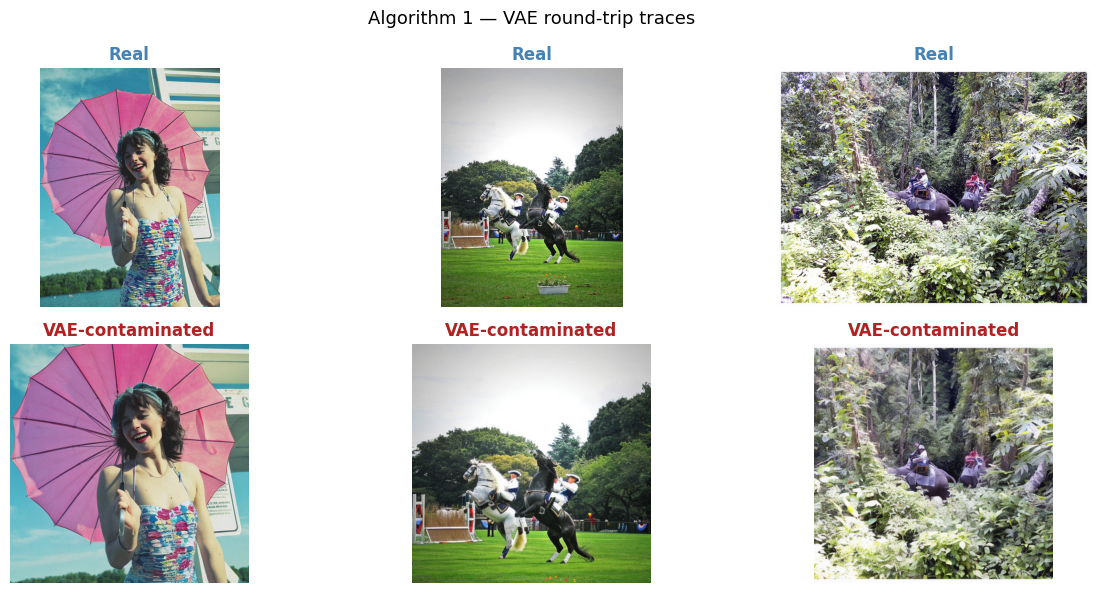

Pixel difference (mean abs): 0.10607273131608963


In [14]:
# ── visual check: real vs. VAE-contaminated

def to_pil(t):
    t = t.cpu()  
    if t.ndim == 4:
        arr = ((t * 0.5 + 0.5).clamp(0,1).permute(1,2,3,0).squeeze().numpy() * 255).astype(np.uint8)
    else:
        arr = ((t * 0.5 + 0.5).clamp(0,1).permute(1,2,0).numpy() * 255).astype(np.uint8)
    return Image.fromarray(arr)


if Path(CFG["coco_dir"]).exists():
    probe_pil = sample_pil[:3]
    probe_t   = torch.stack([transform_vae(img) for img in probe_pil])
    probe_hat = vae_contaminate_batch(probe_t)

    fig, axes = plt.subplots(2, 3, figsize=(13, 6))
    for j in range(3):
        axes[0, j].imshow(probe_pil[j])
        axes[0, j].set_title("Real", color="steelblue", fontweight="bold")
        axes[1, j].imshow(to_pil(probe_hat[j]))
        axes[1, j].set_title("VAE-contaminated", color="firebrick", fontweight="bold")
        for ax in axes[:, j]: ax.axis("off")
    plt.suptitle("Algorithm 1 — VAE round-trip traces", fontsize=13)
    plt.tight_layout()
    plt.show()
    print("Pixel difference (mean abs):",
          (probe_t.cpu() - probe_hat.cpu()).abs().mean().item())

## 3 — Detector model — DINOv2 + FC head

In [17]:
# ── detector: DINOv2 backbone + single linear head (paper §3.3) ───────────────

class DINOv2Detector(nn.Module):
    """DINOv2 ViT backbone with a single binary classification head."""
    def __init__(self, backbone_name: str):
        super().__init__()
        self.backbone = torch.hub.load(
            "facebookresearch/dinov2", backbone_name, pretrained=True
        )
        # Gel des paramètres du backbone
        for param in self.backbone.parameters():
            param.requires_grad = False
        self.head = nn.Linear(self.backbone.embed_dim, 1)

    def forward(self, x):                    # x: (B, 3, 224, 224)
        return self.head(self.backbone(x)).squeeze(-1)   # → (B,) logits

# ── instantiate ──────────────────────────────────────────────────────────────
detector = DINOv2Detector(CFG["backbone"]).to(CFG["device"])
total_params = sum(p.numel() for p in detector.parameters())
trainable    = sum(p.numel() for p in detector.parameters() if p.requires_grad)
print(f"Total params : {total_params:,}")
print(f"Trainable    : {trainable:,}  (only the head is trained)")
print(f"Feature dim  : {detector.backbone.embed_dim}")

Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Total params : 304,369,665
Trainable    : 1,025  (only the head is trained)
Feature dim  : 1024


## 4 — Training loop

**Property 2** of the paper shows that sampling real and fake mini-batches *independently* (not as matched pairs) gives lower gradient variance, leading to faster and more stable convergence.  Two separate `DataLoader`s implement this.

In [56]:
# ==== Exclusive kaggle code ====
import shutil
import os

# Chemin du dossier à compresser (remplace par le nom de ton dossier)
dossier_a_compresser = "/kaggle/working/contaminated_val"  # ou "contaminated_val"

# Nom du fichier zip de sortie
nom_zip = f"{dossier_a_compresser.split('/')[-1]}.zip"

# Compression
shutil.make_archive(dossier_a_compresser, 'zip', dossier_a_compresser)

print(f"Dossier compressé en : {nom_zip}")


Dossier compressé en : contaminated_val.zip


In [51]:
# ── build data loaders ────────────────────────────────────────────────────────

REAL_DIR = CFG["coco_dir"]          # real images
REAL_DIR_val = "/kaggle/input/datasets/kaveeh/image-detection-last-layer/coco-2014/coco-2014/validation/data"
FAKE_VAE_DIR_train   = "/kaggle/input/datasets/kaveeh/image-detection-last-layer/contaminated_train"          
FAKE_VAE_DIR_val   = "/kaggle/input/datasets/kaveeh/image-detection-last-layer/contaminated_val"  

def make_loaders(real_dir: str, fake_dir: str, batch_size: int, num_workers: int = 4):
    """
    Two *independent* loaders — one for real, one for fake.
    Property 2: independent shuffling reduces gradient variance vs. paired loading.
    """
    real_ds = ImageFolderFlat(real_dir, transform_224, label=1)
    fake_ds = ImageFolderFlat(fake_dir, transform_224, label=0)

    real_loader = DataLoader(real_ds, batch_size=batch_size // 2,
                             shuffle=True, num_workers=num_workers,
                             pin_memory=(CFG["device"] == "cuda"), drop_last=True)
    fake_loader = DataLoader(fake_ds, batch_size=batch_size // 2,
                             shuffle=True, num_workers=num_workers,
                             pin_memory=(CFG["device"] == "cuda"), drop_last=True)
    return real_loader, fake_loader


# ── training: one epoch ───────────────────────────────────────────────────────
def train_one_epoch(model, real_loader, fake_loader, optimiser, criterion, device):
    model.train()
    total_loss = total_correct = total_n = 0

    real_iter = iter(real_loader)
    fake_iter = iter(fake_loader)
    steps = min(len(real_loader), len(fake_loader))

    for _ in range(steps):
        try:
            rx, ry = next(real_iter)
            fx, fy = next(fake_iter)
        except StopIteration:
            break

        # merge independently-shuffled mini-batches (Property 2)
        x = torch.cat([rx, fx]).to(device)
        y = torch.cat([ry, fy]).to(device)

        y_hat = model(x)
        loss   = criterion(y_hat, y)

        optimiser.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()

        preds = (torch.sigmoid(y_hat) >= 0.5).long()
        total_correct += (preds == y.long()).sum().item()
        total_loss    += loss.item() * len(y)
        total_n       += len(y)

    return total_loss / max(total_n, 1), total_correct / max(total_n, 1)


# ── validation ────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, real_loader, fake_loader, device, criterion):
    model.eval()
    all_probs = []
    all_labels = []
    total_loss = 0.0
    total_n = 0

    for loader, label_val in [(real_loader, 1), (fake_loader, 0)]:
        for x, _ in loader:
            x = x.to(device)
            y = torch.full((len(x),), label_val, device=device, dtype=torch.float32)  # <-- Correction
            y_hat = model(x)
            loss = criterion(y_hat, y)
            total_loss += loss.item() * len(y)
            total_n += len(y)
            probs = torch.sigmoid(y_hat).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend([label_val] * len(probs))

    if total_n == 0:
        raise ValueError("Aucun échantillon n'a été traité. Vérifiez les loaders.")

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    preds = (all_probs >= 0.5).astype(int)
    acc = accuracy_score(all_labels, preds)
    ap = average_precision_score(all_labels, all_probs)
    val_loss = total_loss / total_n
    return acc, ap, val_loss, all_probs, all_labels


# ── full training loop ────────────────────────────────────────────────────────
def train(
    model,
    real_dir: str,
    fake_dir: str,
    val_real_dir: str = None,
    val_fake_dir: str = None,
    epochs: int = None,
    batch_size: int = None,
    lr: float = 1*10**(-4), # the learning rate of the paper
    ckpt_path: str = None,
):
    epochs     = epochs     or CFG["epochs"]
    batch_size = batch_size or CFG["batch_size"]
    lr         = lr         or CFG["lr"]
    ckpt_path  = ckpt_path  or CFG["ckpt_path"]
    device     = CFG["device"]

    train_real, train_fake = make_loaders(real_dir, fake_dir, batch_size)
    val_real, val_fake     = (make_loaders(val_real_dir, val_fake_dir, batch_size))
    print(f"Nombre de batches dans val_real: {len(val_real)}")
    print(f"Nombre de batches dans val_fake: {len(val_fake)}")
                              

    criterion  = nn.BCEWithLogitsLoss()
    optimiser  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs)

    history = {"train_loss": [], "train_acc": [], "val_acc": [], "val_ap": [], "val_loss": []}
    best_val_acc = 0.0

    for epoch in range(1, epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_real, train_fake,
                                        optimiser, criterion, device)
        v_acc, v_ap,val_loss, _, _ = evaluate(model, val_real, val_fake, device,criterion)
        scheduler.step()

        history["train_loss"].append(t_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)
        history["val_ap"].append(v_ap)
        history["val_loss"].append(val_loss)

        log.info(f"Epoch {epoch:03d}/{epochs}  "
                 f"loss={t_loss:.4f}  train_acc={t_acc*100:.1f}%  "
                 f"val_acc={v_acc*100:.1f}%  AP={v_ap:.4f}")

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save(model.state_dict(), ckpt_path)
            log.info(f"  ↳ Best val_acc={v_acc*100:.2f}% — saved to {ckpt_path}")

    return history

In [52]:
# ── run training ───────────────────────────────
history = train(detector, REAL_DIR, FAKE_VAE_DIR_train,REAL_DIR_val,FAKE_VAE_DIR_val)

Nombre de batches dans val_real: 15
Nombre de batches dans val_fake: 15


In [ ]:
# ── plot training curves ──────────────────────────────────────────────────────
def plot_training(history: dict):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(history["train_loss"], label="Train loss", color="firebrick")
    ax1.plot(history["val_loss"], label="Validation loss", color="yellow")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("BCE Loss")
    ax1.set_title("Training & Val Loss"); ax1.legend()

    ax2.plot([a*100 for a in history["train_acc"]], label="Train acc", color="steelblue")
    ax2.plot([a*100 for a in history["val_acc"]],   label="Val acc",   color="darkorange")
    ax2.plot([a*100 for a in history["val_ap"]],    label="Val AP×100",color="forestgreen", linestyle="--")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("%")
    ax2.set_title("Accuracy & Average Precision")
    ax2.legend()

    plt.tight_layout(); plt.show()

plot_training(history)   

In [57]:
pip freeze > requirements.txt 

Note: you may need to restart the kernel to use updated packages.
